In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier



In [ ]:
import os
os.makedirs("plots", exist_ok=True)

In [ ]:
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

In [ ]:
matches.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 636 entries, 0 to 635
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               636 non-null    int64  
 1   season           636 non-null    int64  
 2   city             629 non-null    object 
 3   date             636 non-null    object 
 4   team1            636 non-null    object 
 5   team2            636 non-null    object 
 6   toss_winner      636 non-null    object 
 7   toss_decision    636 non-null    object 
 8   result           636 non-null    object 
 9   dl_applied       636 non-null    int64  
 10  winner           633 non-null    object 
 11  win_by_runs      636 non-null    int64  
 12  win_by_wickets   636 non-null    int64  
 13  player_of_match  633 non-null    object 
 14  venue            636 non-null    object 
 15  umpire1          635 non-null    object 
 16  umpire2          635 non-null    object 
 17  umpire3         

In [ ]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150460 entries, 0 to 150459
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          150460 non-null  int64 
 1   inning            150460 non-null  int64 
 2   batting_team      150460 non-null  object
 3   bowling_team      150460 non-null  object
 4   over              150460 non-null  int64 
 5   ball              150460 non-null  int64 
 6   batsman           150460 non-null  object
 7   non_striker       150460 non-null  object
 8   bowler            150460 non-null  object
 9   is_super_over     150460 non-null  int64 
 10  wide_runs         150460 non-null  int64 
 11  bye_runs          150460 non-null  int64 
 12  legbye_runs       150460 non-null  int64 
 13  noball_runs       150460 non-null  int64 
 14  penalty_runs      150460 non-null  int64 
 15  batsman_runs      150460 non-null  int64 
 16  extra_runs        150460 non-null  int

In [ ]:
matches.isnull().sum()

,0
id,0
season,0
city,7
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [ ]:
# Fill missing values
matches['city'] = matches['city'].fillna('Unknown')
matches['winner'] = matches['winner'].fillna('No Result')
matches['player_of_match'] = matches['player_of_match'].fillna('Unknown')
matches['umpire1'] = matches['umpire1'].fillna('Unknown')
matches['umpire2'] = matches['umpire2'].fillna('Unknown')

In [ ]:
matches.isnull().sum()

,0
id,0
season,0
city,0
date,0
team1,0
team2,0
toss_winner,0
toss_decision,0
result,0
dl_applied,0


In [ ]:
deliveries.isnull().sum()

,0
match_id,0
inning,0
batting_team,0
bowling_team,0
over,0
ball,0
batsman,0
non_striker,0
bowler,0
is_super_over,0


In [ ]:
# Fill player dismissed column
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna('Not Out')

# Fill dismissal kind
deliveries['dismissal_kind'] = deliveries['dismissal_kind'].fillna('None')

# Fill fielder column
deliveries['fielder'] = deliveries['fielder'].fillna('Not Applicable')

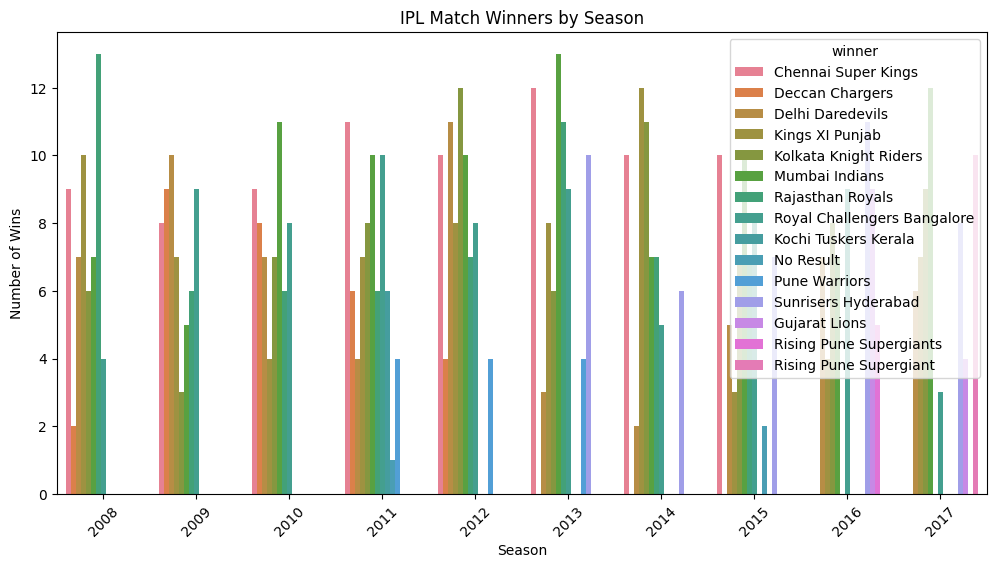

In [ ]:
winner_by_year = matches.groupby(['season','winner']).size().reset_index(name='wins')

plt.figure(figsize=(12,6))
sns.barplot(data=winner_by_year, x='season', y='wins', hue='winner')

plt.title("IPL Match Winners by Season")
plt.xlabel("Season")
plt.ylabel("Number of Wins")
plt.xticks(rotation=45)
plt.savefig("winner_by_year.png", dpi=300, bbox_inches='tight')

plt.show()

Total Super Over Deliveries: 81


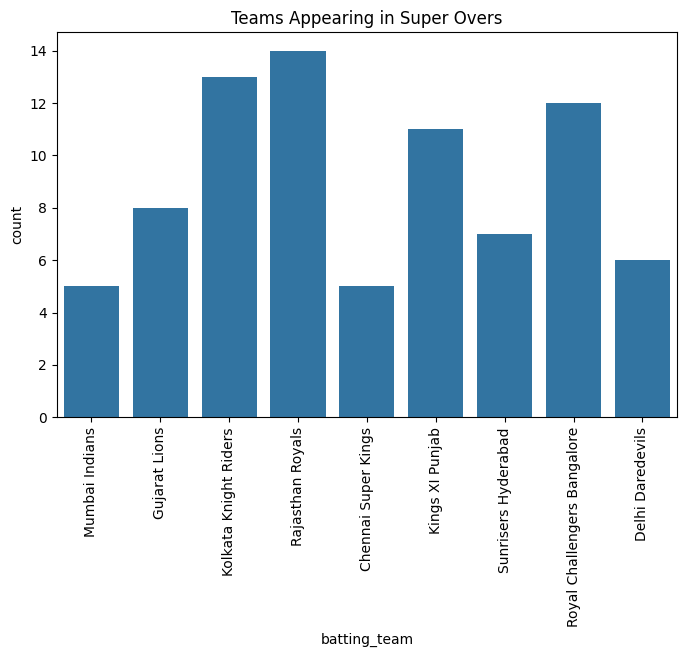

In [ ]:
super_over = deliveries[deliveries['is_super_over'] == 1]

print("Total Super Over Deliveries:", len(super_over))

plt.figure(figsize=(8,5))
sns.countplot(x='batting_team', data=super_over)

plt.title("Teams Appearing in Super Overs")
plt.xticks(rotation=90)

# Save the plot
plt.savefig("super_over_analysis.png", dpi=300, bbox_inches='tight')

plt.show()

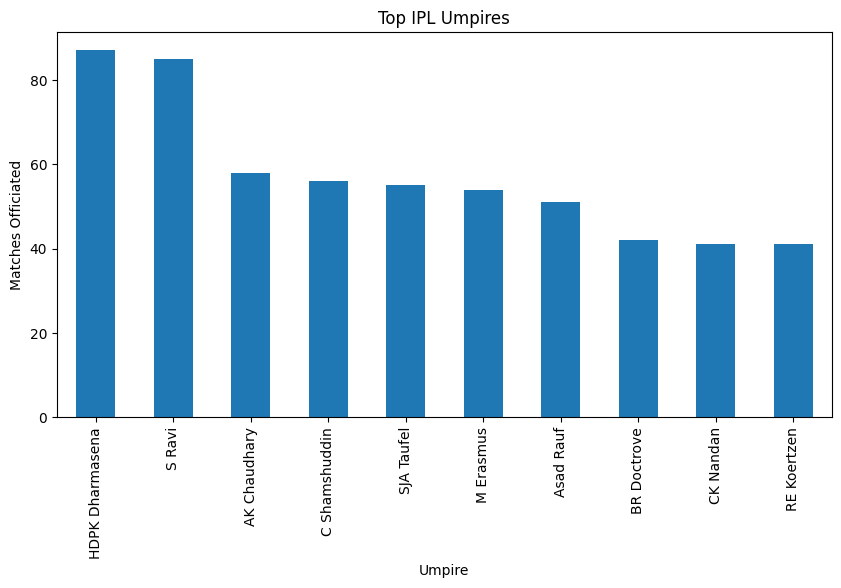

In [ ]:


umpire_counts = pd.concat([matches['umpire1'], matches['umpire2']]).value_counts().head(10)

plt.figure(figsize=(10,5))
umpire_counts.plot(kind='bar')

plt.title("Top IPL Umpires")
plt.xlabel("Umpire")
plt.ylabel("Matches Officiated")

# Save image
plt.savefig("plots/umpire_trends.png", dpi=300, bbox_inches='tight')

plt.show()

Number of 200+ innings: 67


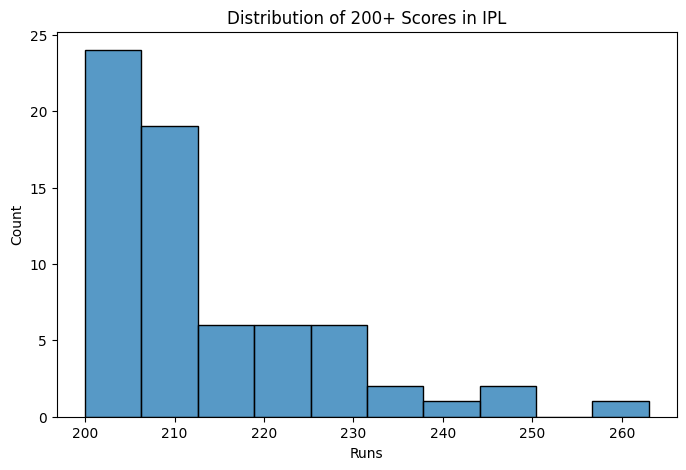

In [ ]:
# Calculate total runs per innings
runs_per_innings = deliveries.groupby(['match_id','inning'])['total_runs'].sum().reset_index()

# Filter 200+ scores
high_scores = runs_per_innings[runs_per_innings['total_runs'] >= 200]

print("Number of 200+ innings:", len(high_scores))

plt.figure(figsize=(8,5))
sns.histplot(high_scores['total_runs'], bins=10)

plt.title("Distribution of 200+ Scores in IPL")
plt.xlabel("Runs")

# Save image
plt.savefig("plots/high_scoring_matches.png", dpi=300, bbox_inches='tight')

plt.show()

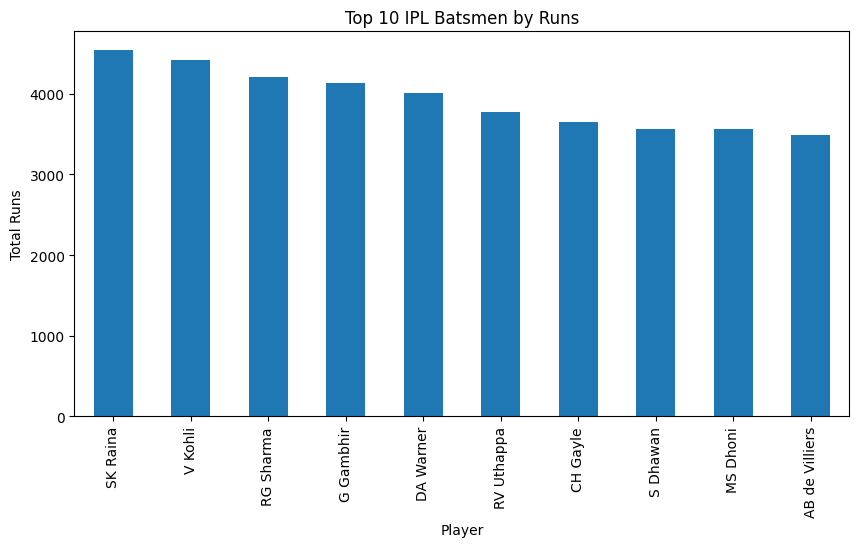

In [ ]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_batsmen.plot(kind='bar')

plt.title("Top 10 IPL Batsmen by Runs")
plt.xlabel("Player")
plt.ylabel("Total Runs")
plt.show()

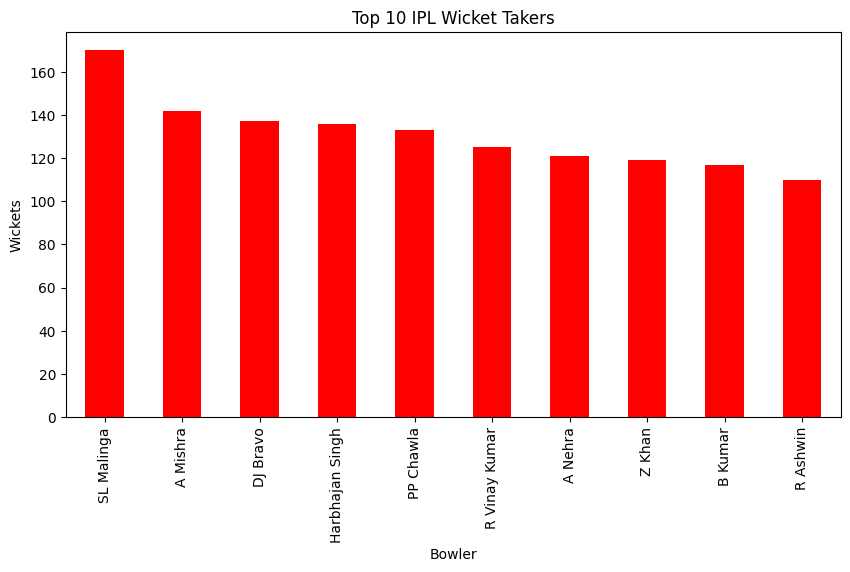

In [ ]:
wickets = deliveries[deliveries['dismissal_kind'].notna()]

top_bowlers = wickets['bowler'].value_counts().head(10)

plt.figure(figsize=(10,5))
top_bowlers.plot(kind='bar', color='red')

plt.title("Top 10 IPL Wicket Takers")
plt.xlabel("Bowler")
plt.ylabel("Wickets")

# Save the image
plt.savefig("plots/top_10_bowlers_wickets.png", dpi=300, bbox_inches='tight')

plt.show()

In [ ]:
merged = deliveries.merge(matches[['id','season']], left_on='match_id', right_on='id')

season_runs = merged.groupby(['season','batsman'])['batsman_runs'].sum().reset_index()

orange_cap = season_runs.loc[season_runs.groupby('season')['batsman_runs'].idxmax()]

print(orange_cap[['season','batsman','batsman_runs']])

      season       batsman  batsman_runs
115     2008      SE Marsh           616
229     2009     ML Hayden           572
446     2010  SR Tendulkar           618
502     2011      CH Gayle           608
684     2012      CH Gayle           733
910     2013    MEK Hussey           733
1088    2014    RV Uthappa           660
1148    2015     DA Warner           562
1383    2016       V Kohli           973
1422    2017     DA Warner           641


In [ ]:
season_wickets = merged[merged['dismissal_kind'].notna()]

purple_cap = season_wickets.groupby(['season','bowler']).size().reset_index(name='wickets')

purple_cap = purple_cap.loc[purple_cap.groupby('season')['wickets'].idxmax()]

print(purple_cap)

     season         bowler  wickets
77     2008  Sohail Tanvir       24
157    2009       RP Singh       26
248    2010        PP Ojha       22
375    2011     SL Malinga       30
447    2012       M Morkel       30
519    2013       DJ Bravo       34
651    2014      MM Sharma       26
709    2015       DJ Bravo       28
792    2016        B Kumar       24
880    2017        B Kumar       28


In [ ]:
data = matches[['team1','team2','toss_winner','toss_decision','venue','winner']].dropna()

le = LabelEncoder()

for col in data.columns:
    data[col] = le.fit_transform(data[col])

X = data.drop('winner', axis=1)
y = data['winner']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = RandomForestClassifier()
model.fit(X_train,y_train)

print("Model Accuracy:", model.score(X_test,y_test))

Model Accuracy: 0.5546875
